## For in the two-dimensional time–frequency plots
* 1. For the `wideband_full_time` flagging pattern, the `1d_1d` method fails to reconstruct some flagged regions in the two-dimensional time–frequency plots across all tested baselines, which only happen in ideal mock data baseline(0,10)

* 2. For the `wideband_long_time` flagging pattern, the `1d_1d` method fails to reconstruct some flagged regions  for baselines `(0, 5)` and `(0, 10)`,  which only happen in ideal mock data baseline(0,10)

## Results from the Histogram Figures

* The advantage of `2d_1d` over `1d_1d` remains clearly visible for both the `narrowband_long_time` and `wideband_long_time` flagging patterns across all tested baselines, even when using corrupted data instead of ideal data.


gprlim path:
/Users/alliswell48/gprlim/gprlim/__init__.py

utils_inpaint module path:
/Users/alliswell48/radio_gpr_work/shao1/2.corrupt_data/utils_load.py

gp_utils path:
/Users/alliswell48/radio_gpr_work/shao1/2.corrupt_data/../../gp_utils.py


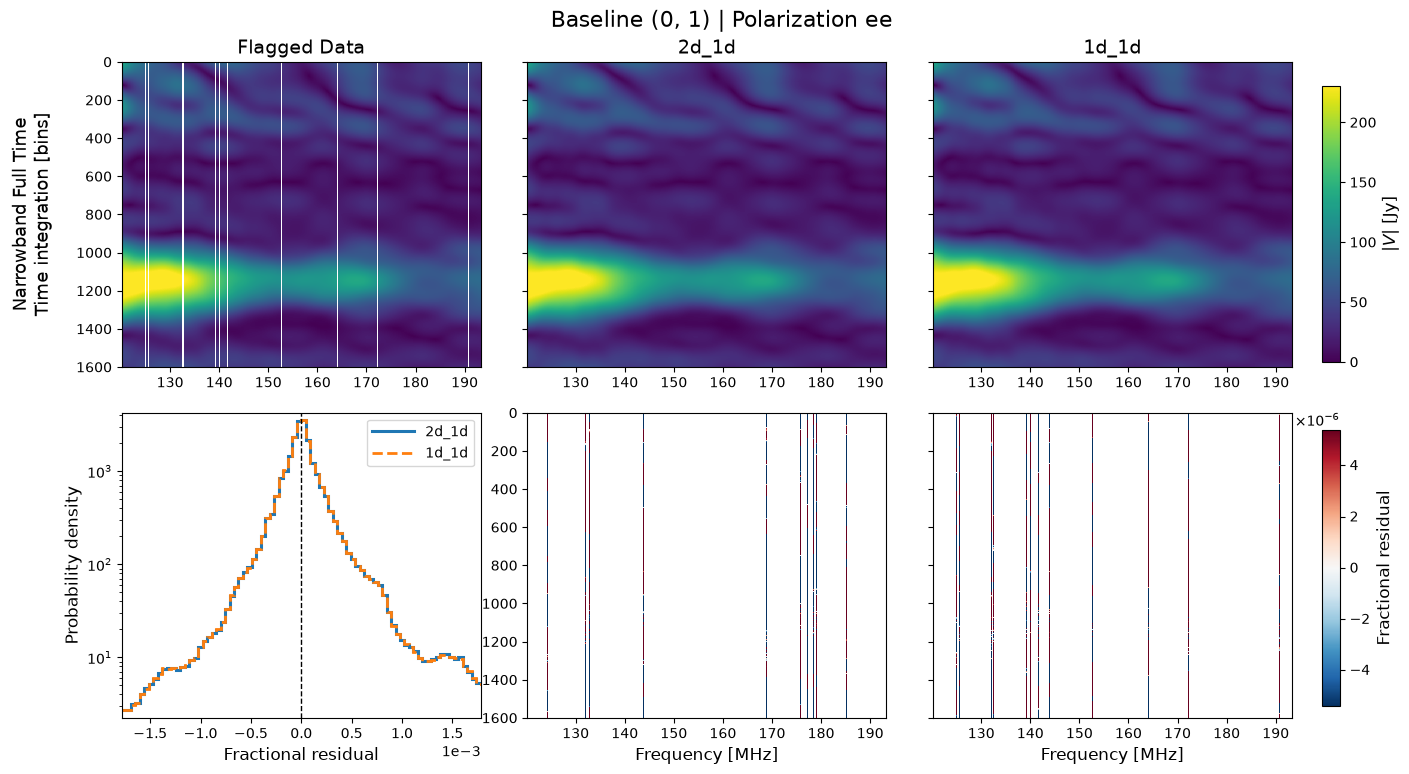

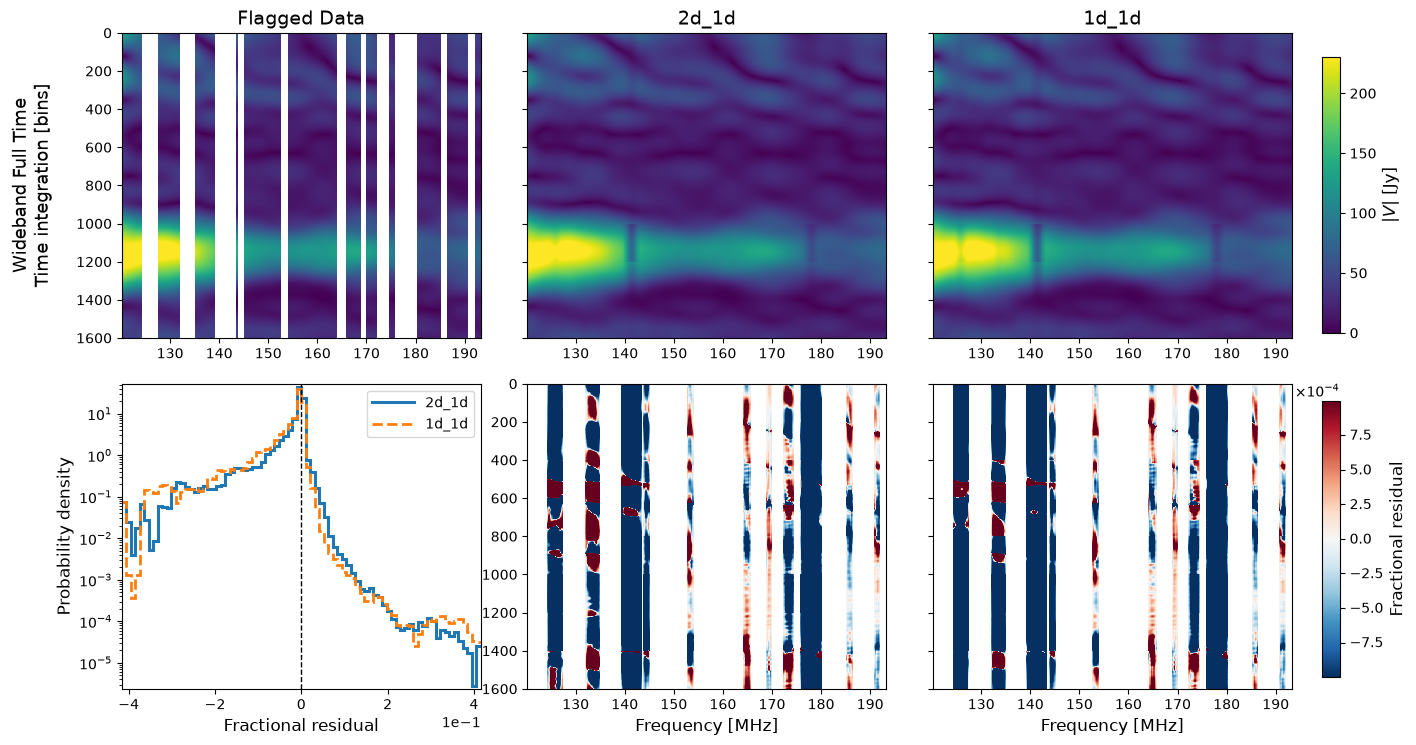

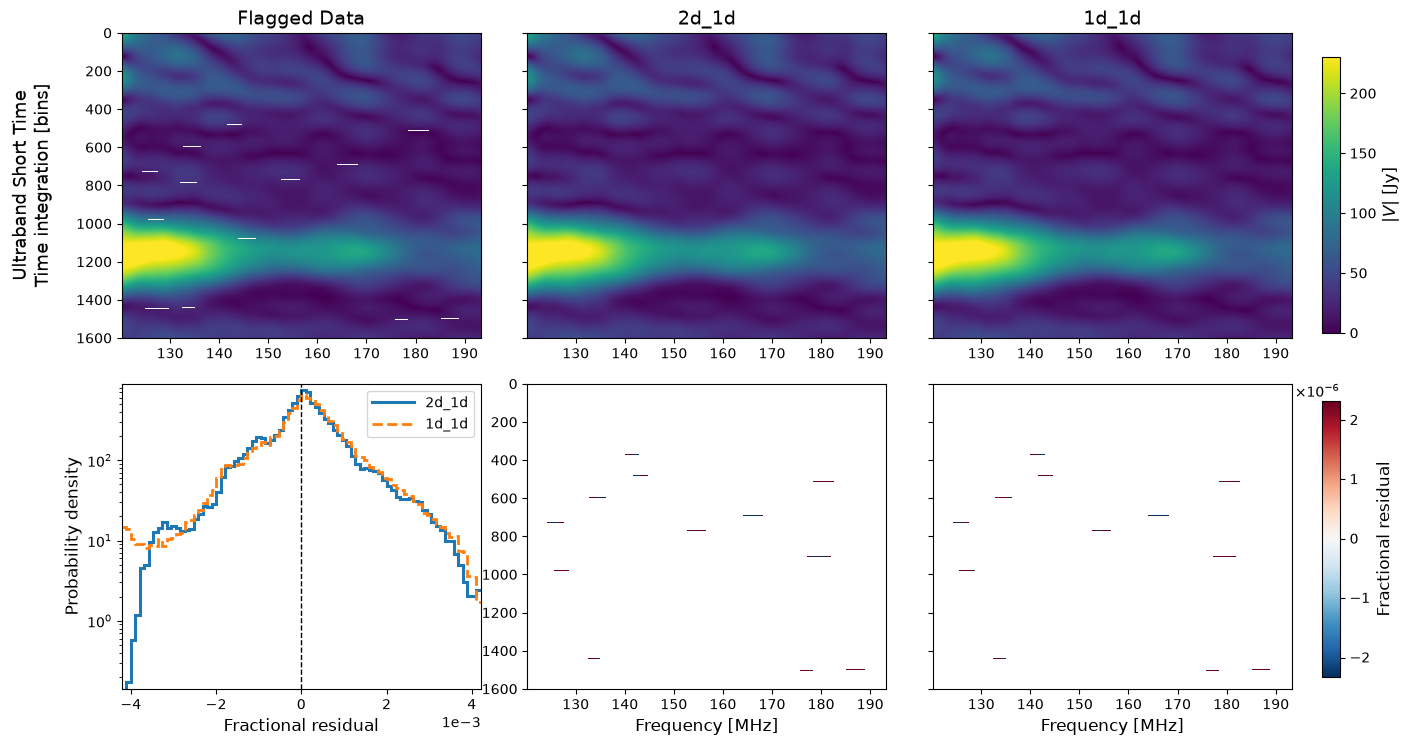

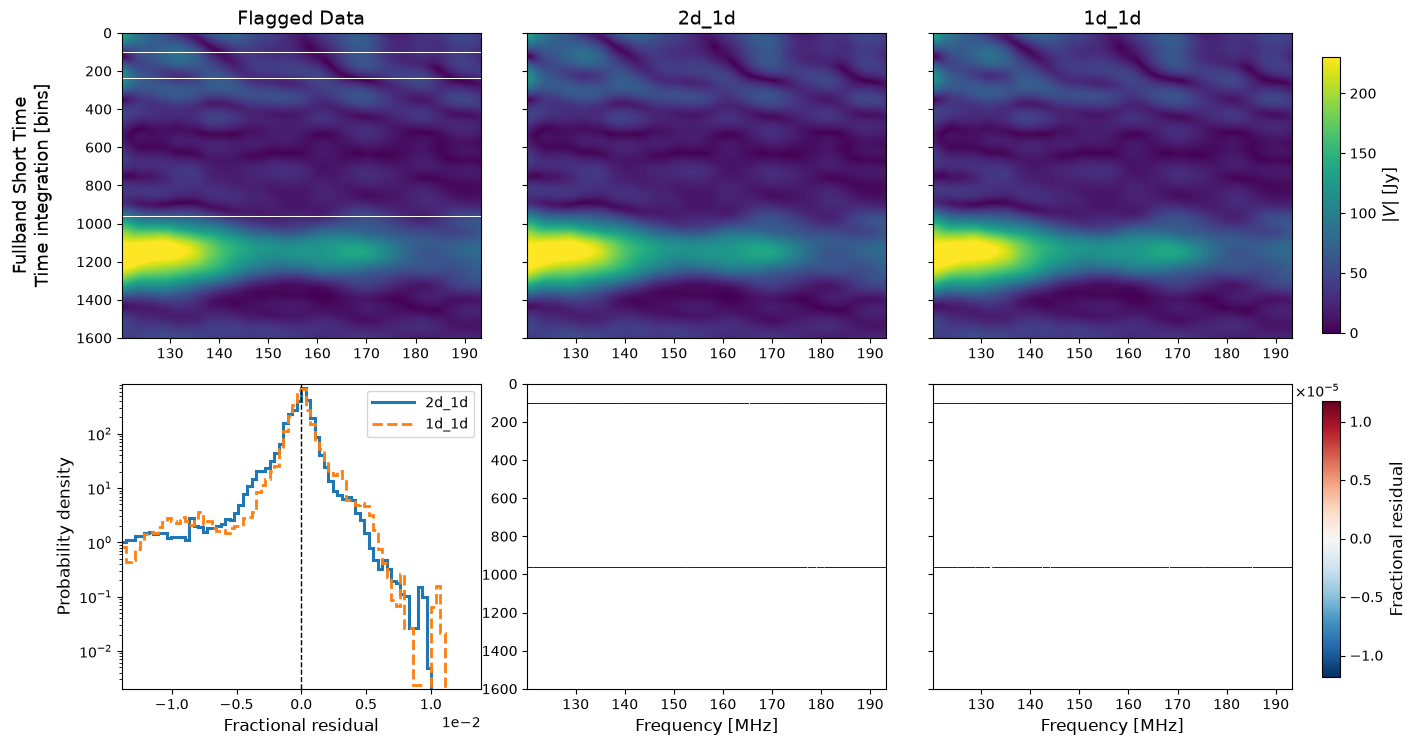

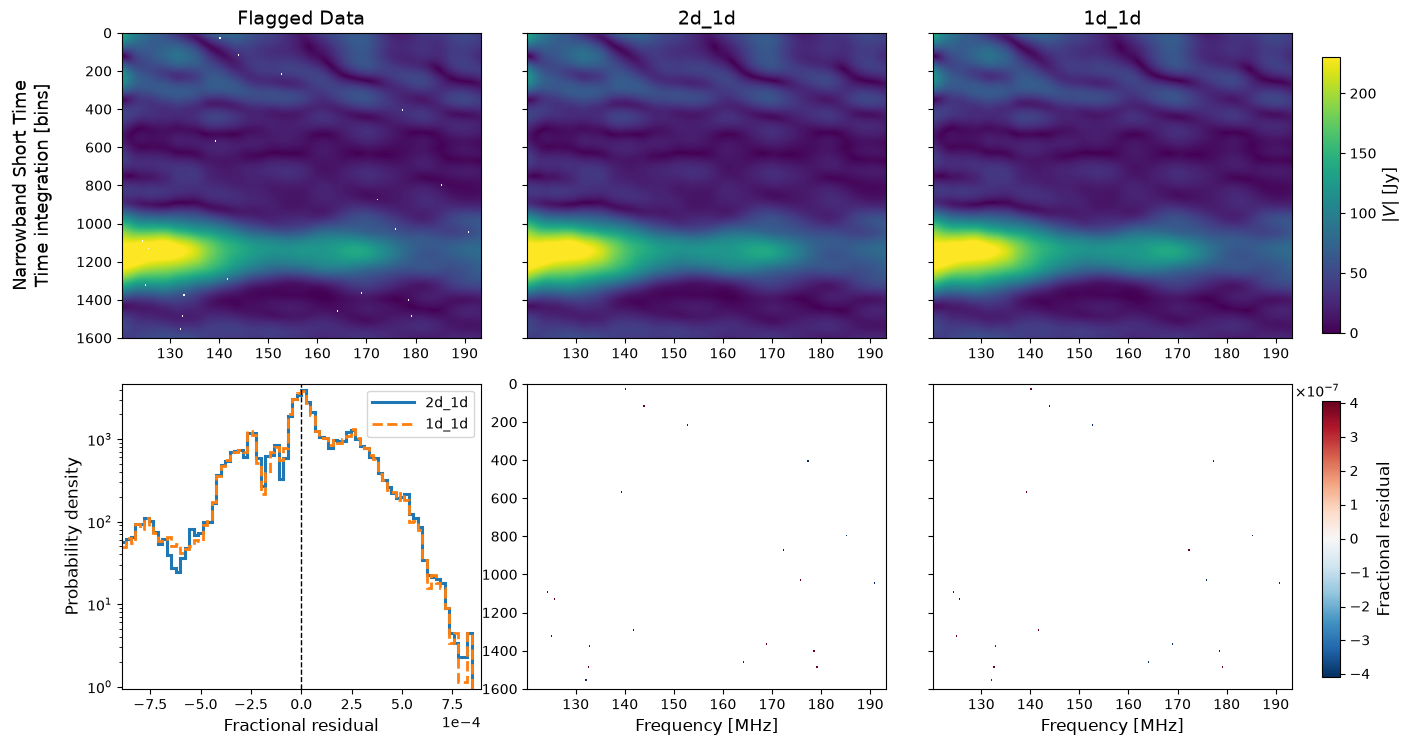

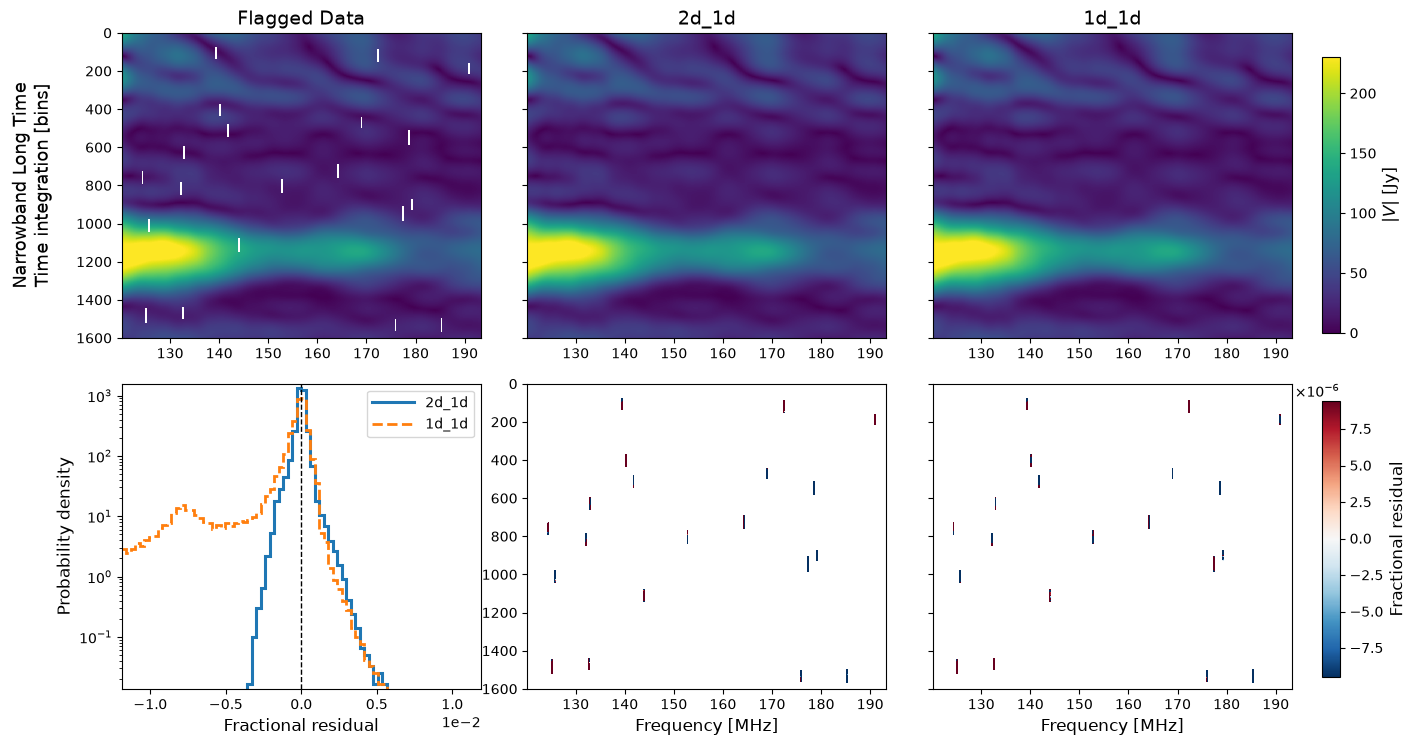

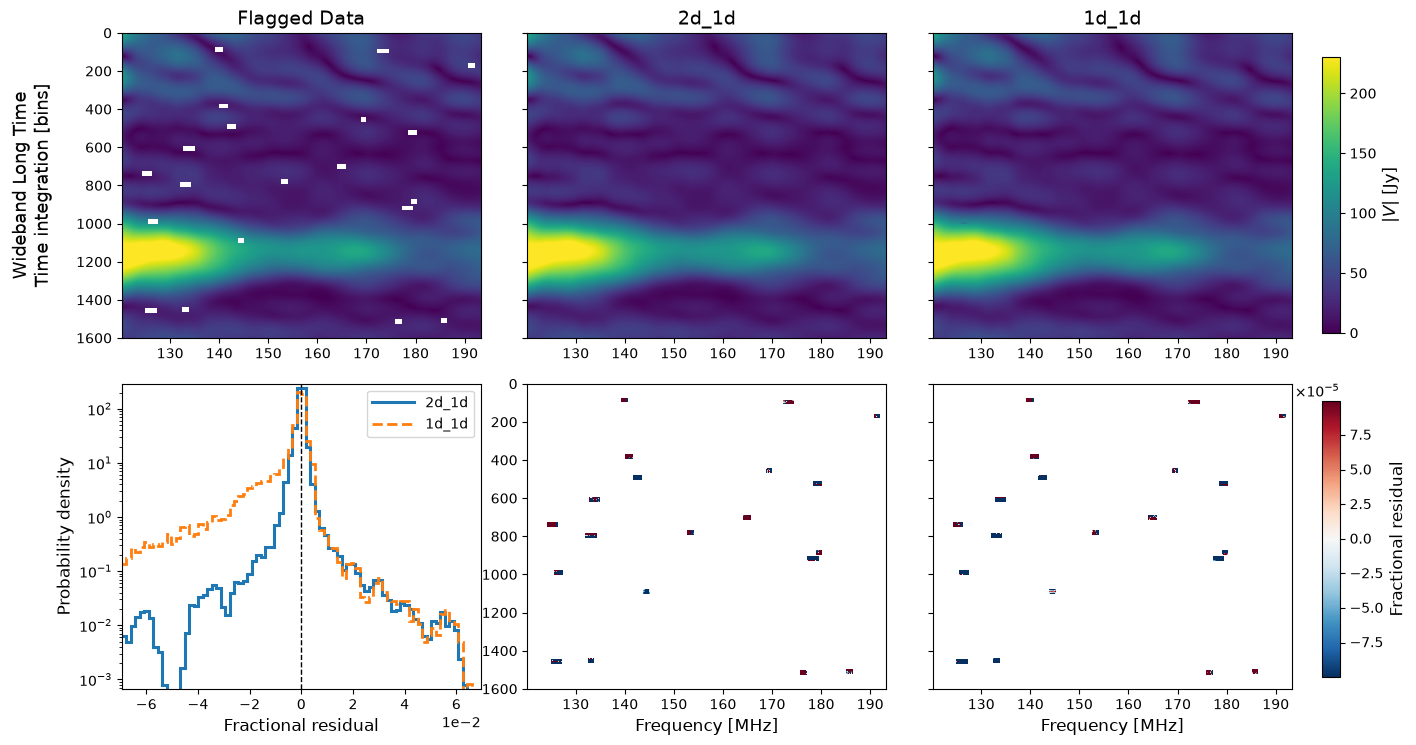

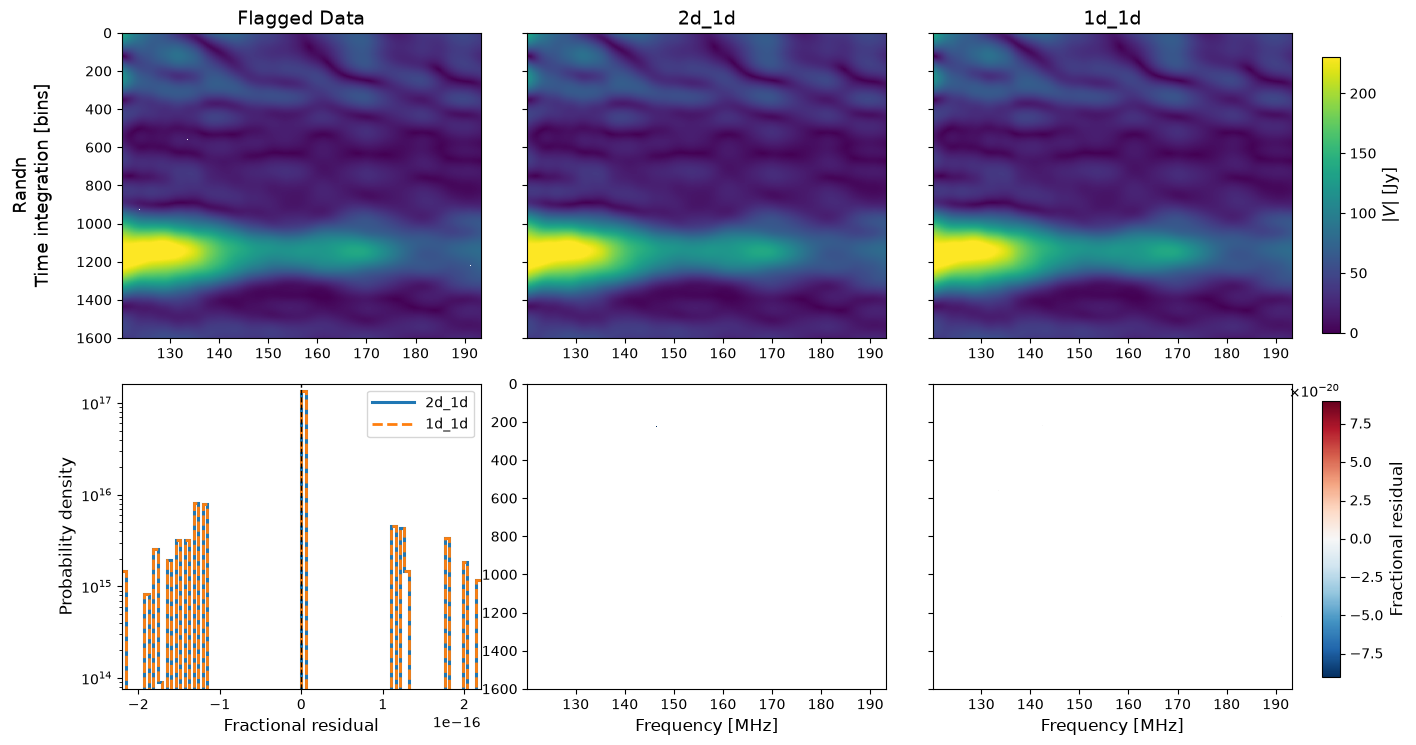

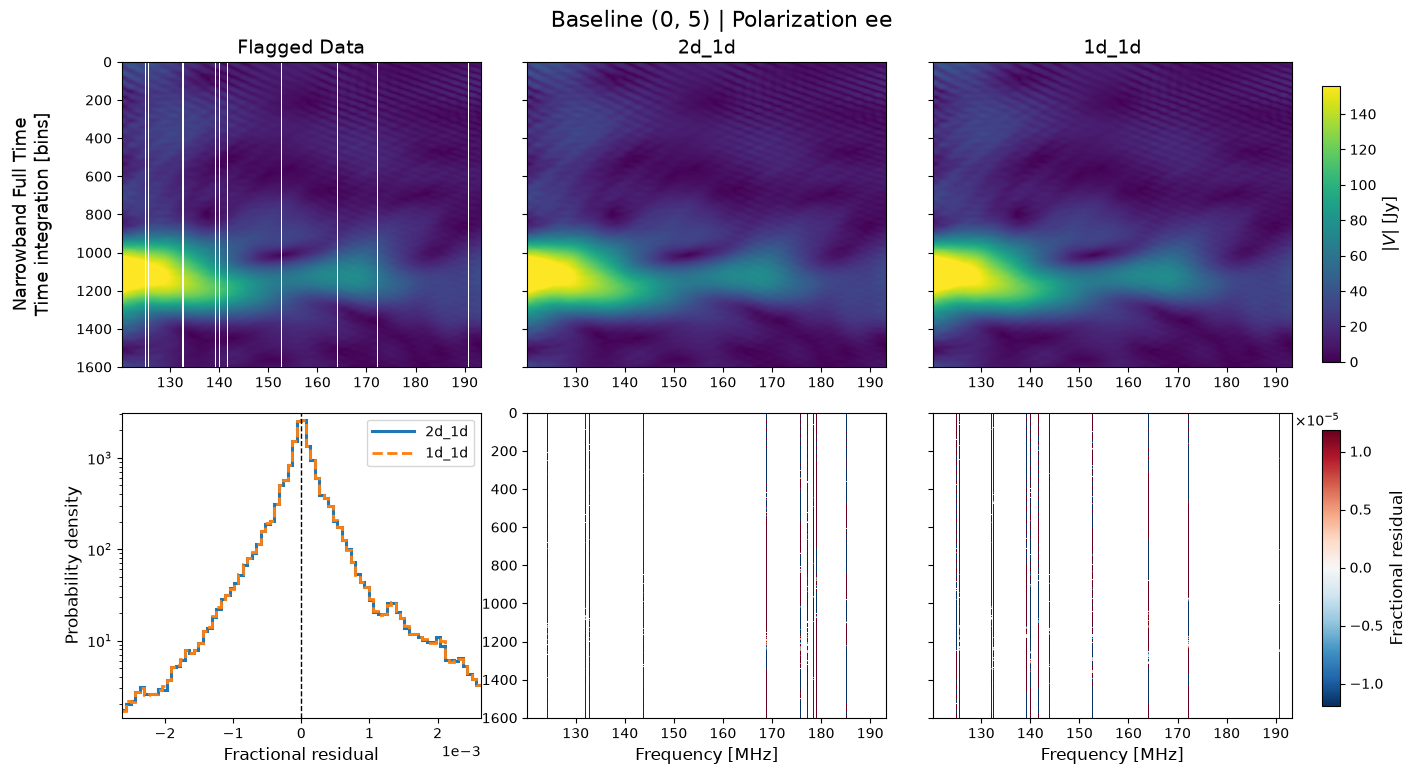

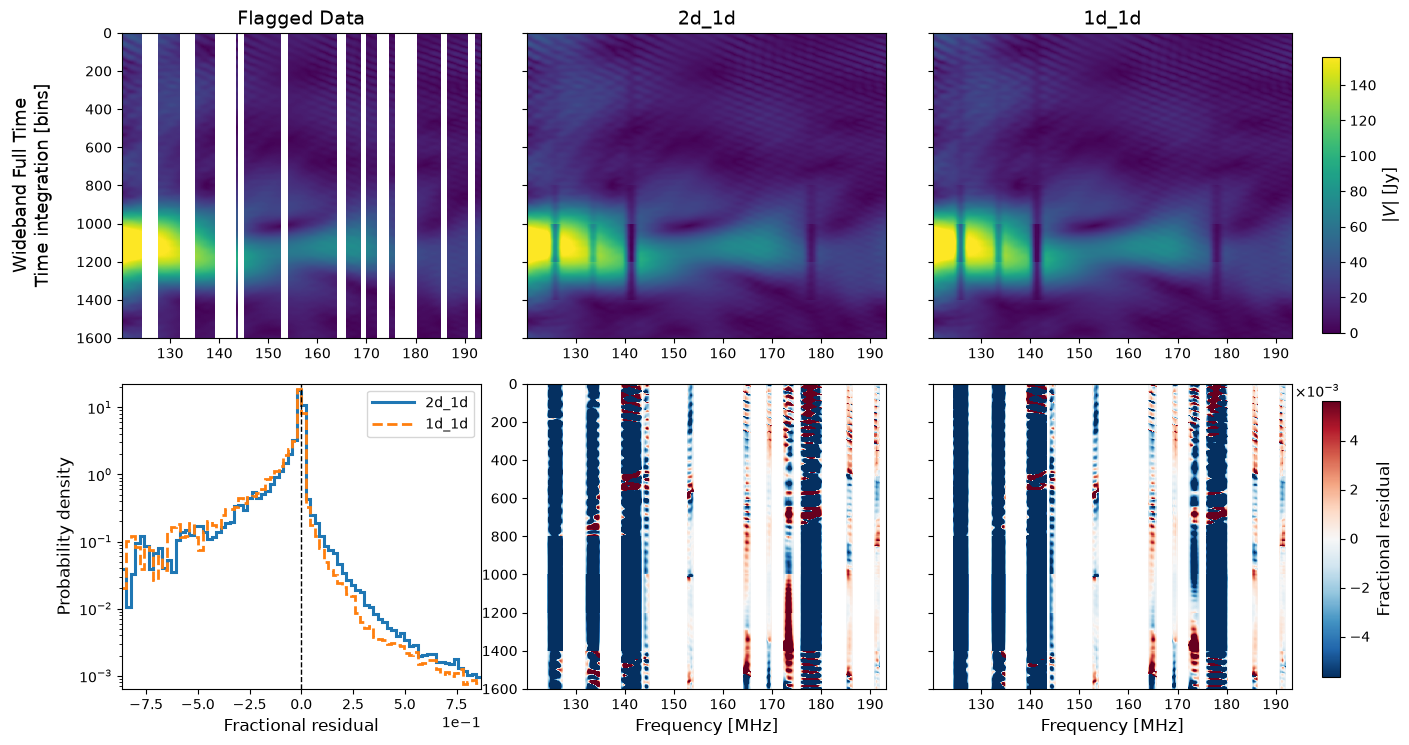

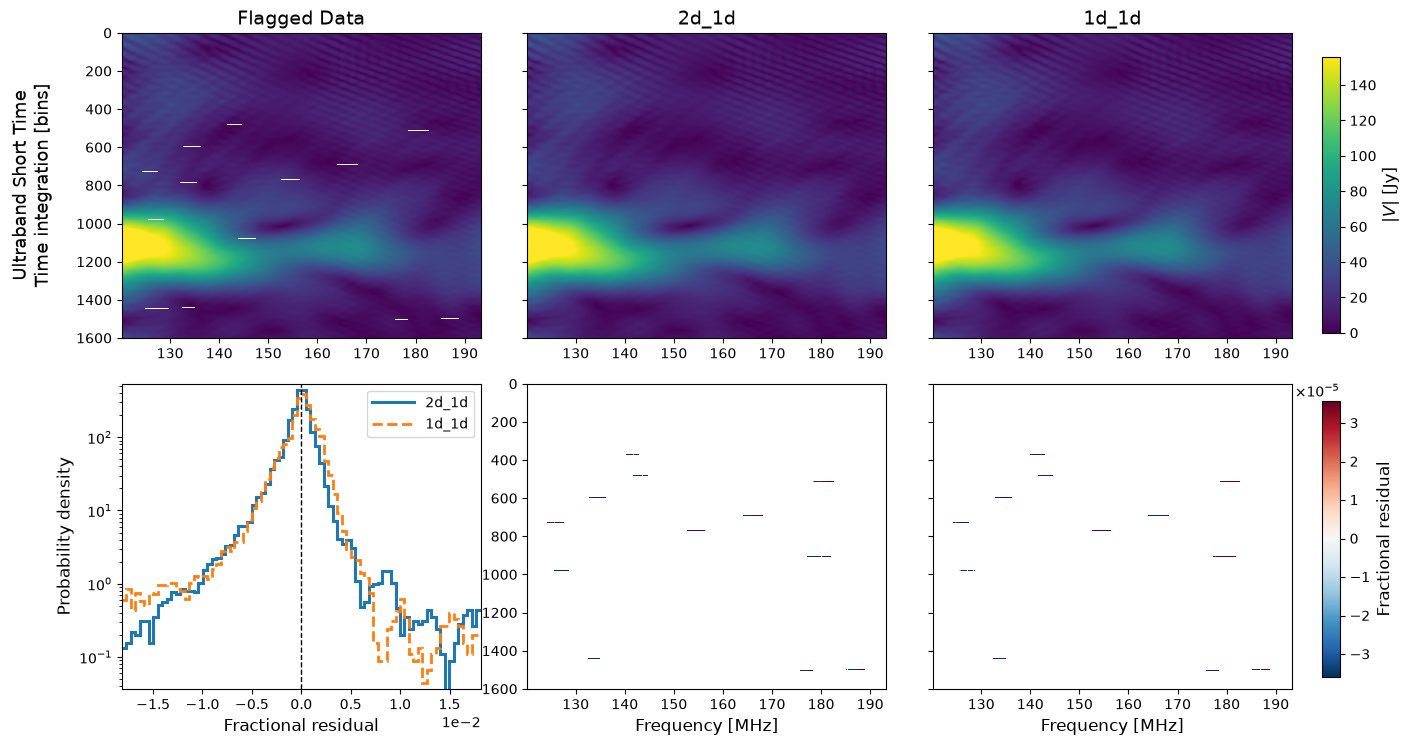

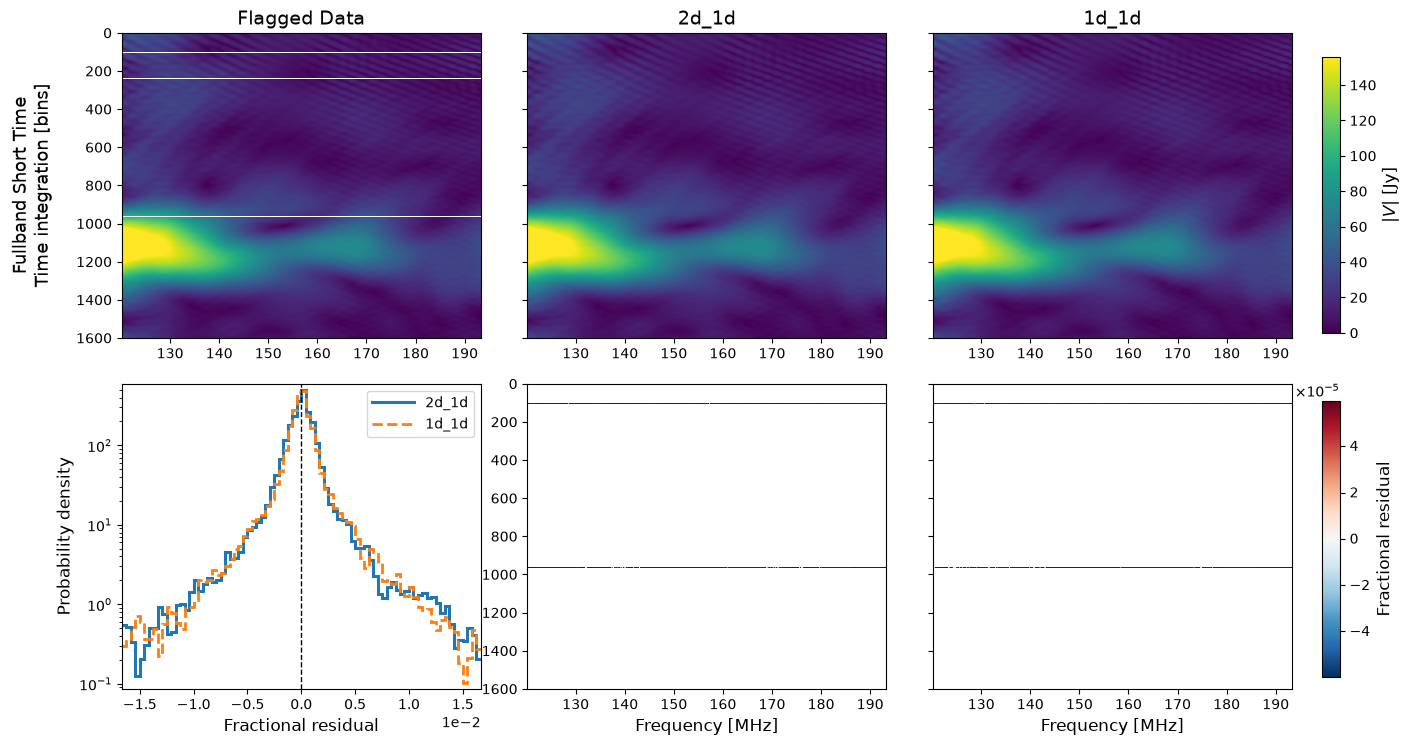

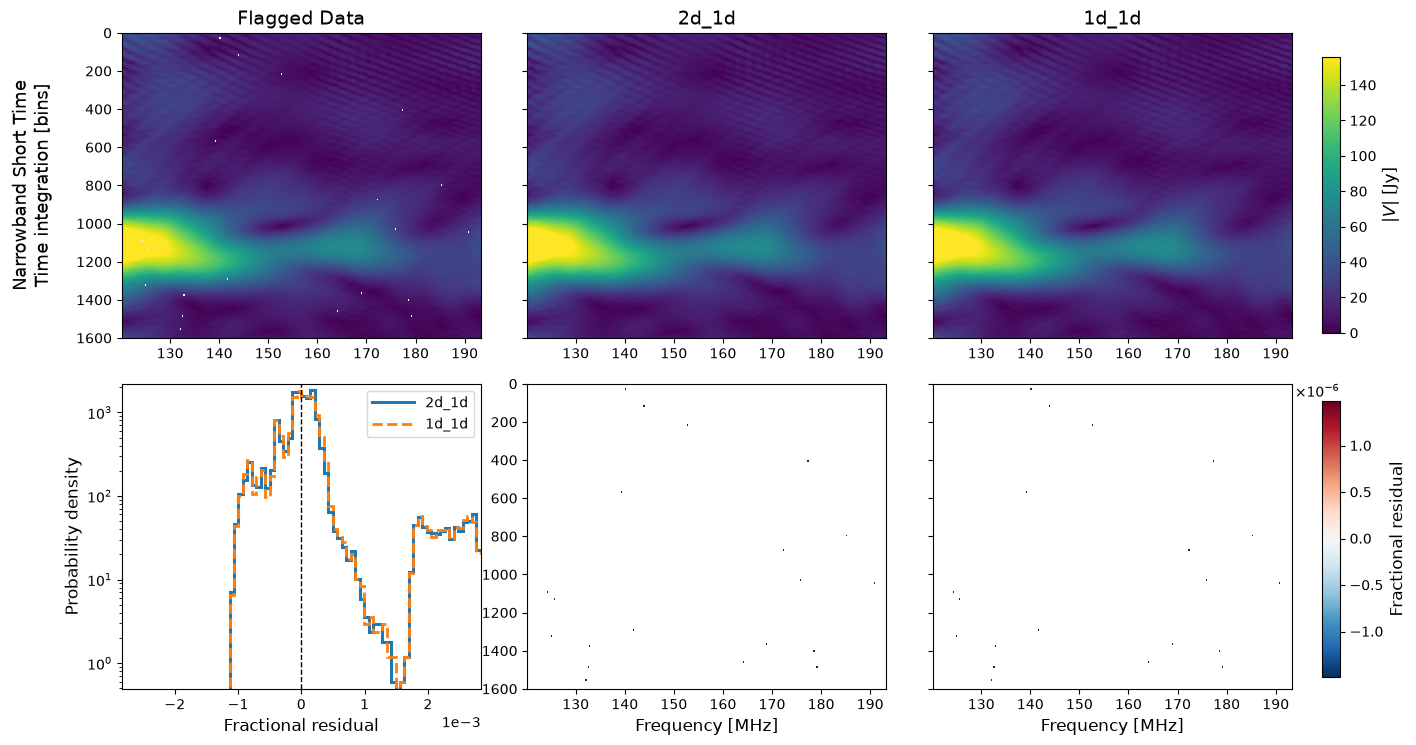

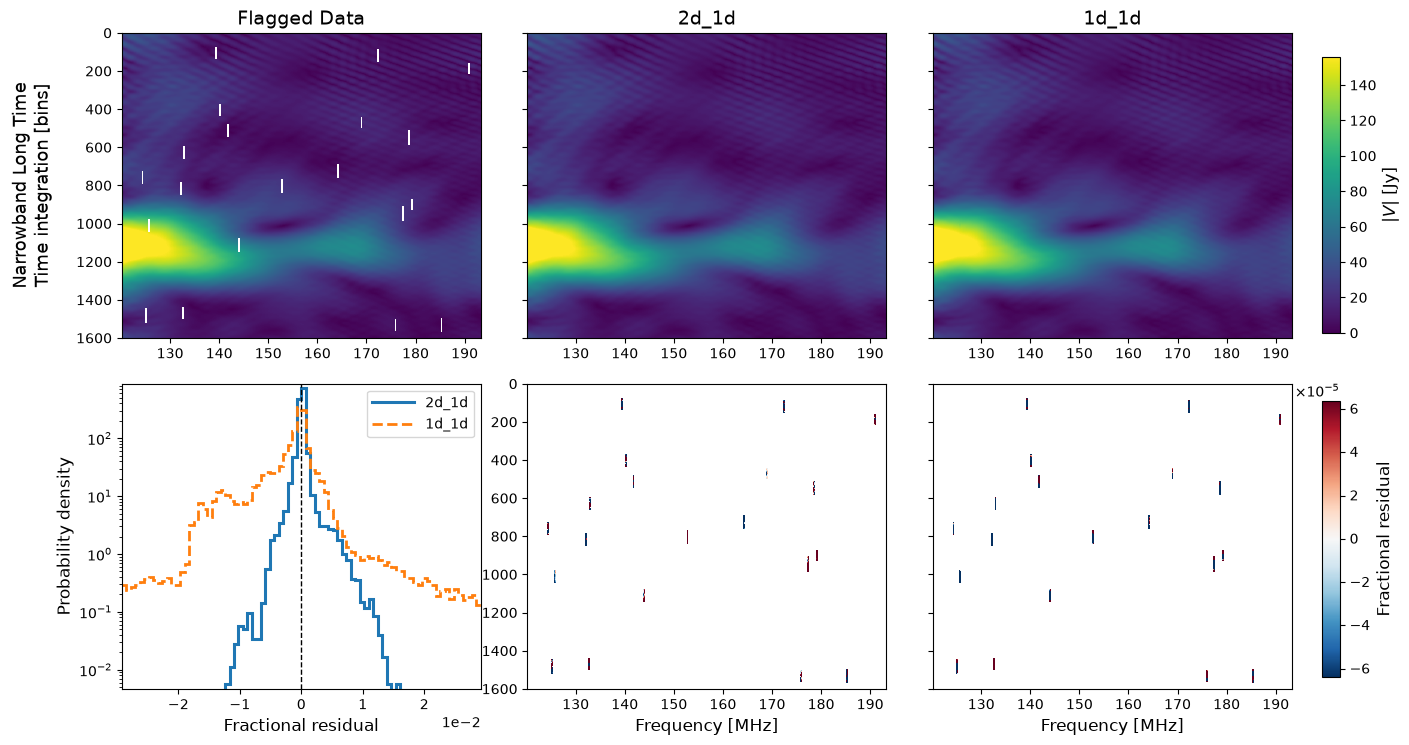

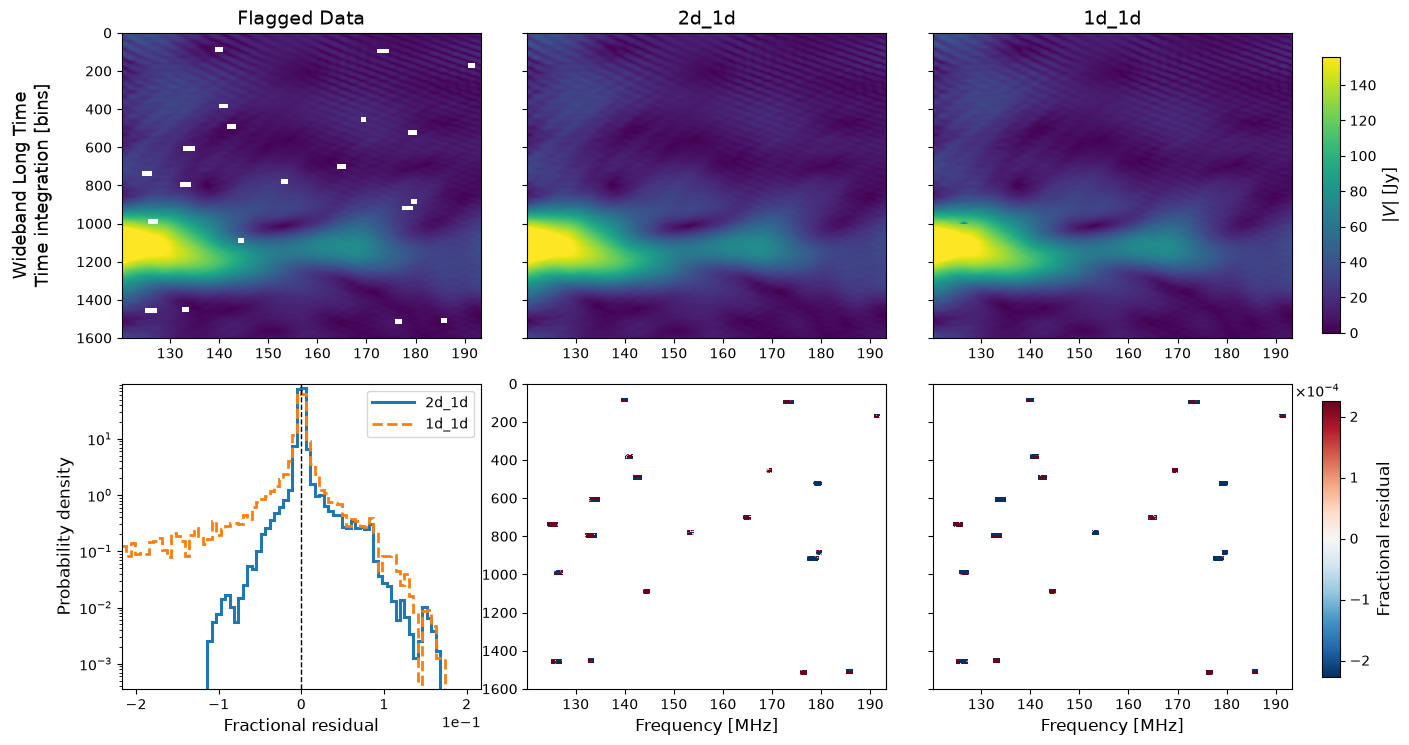

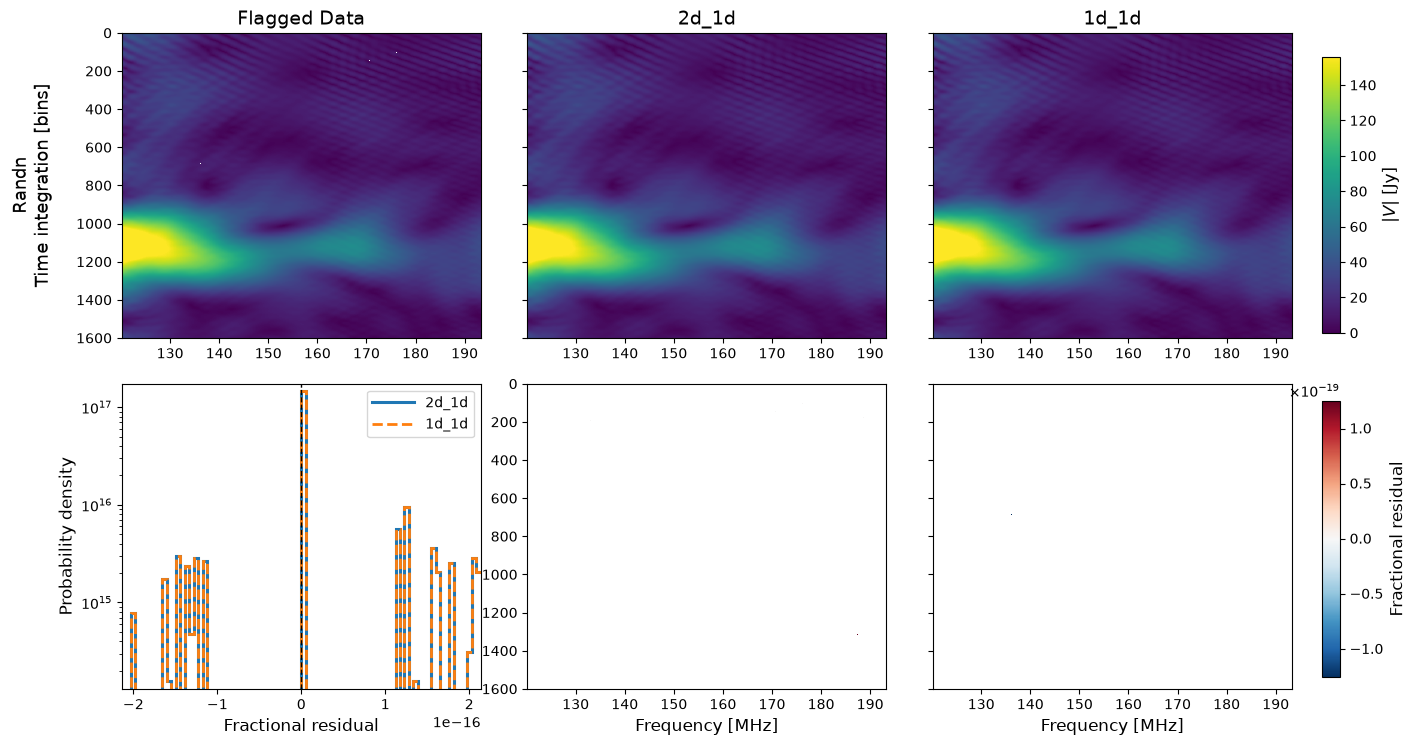

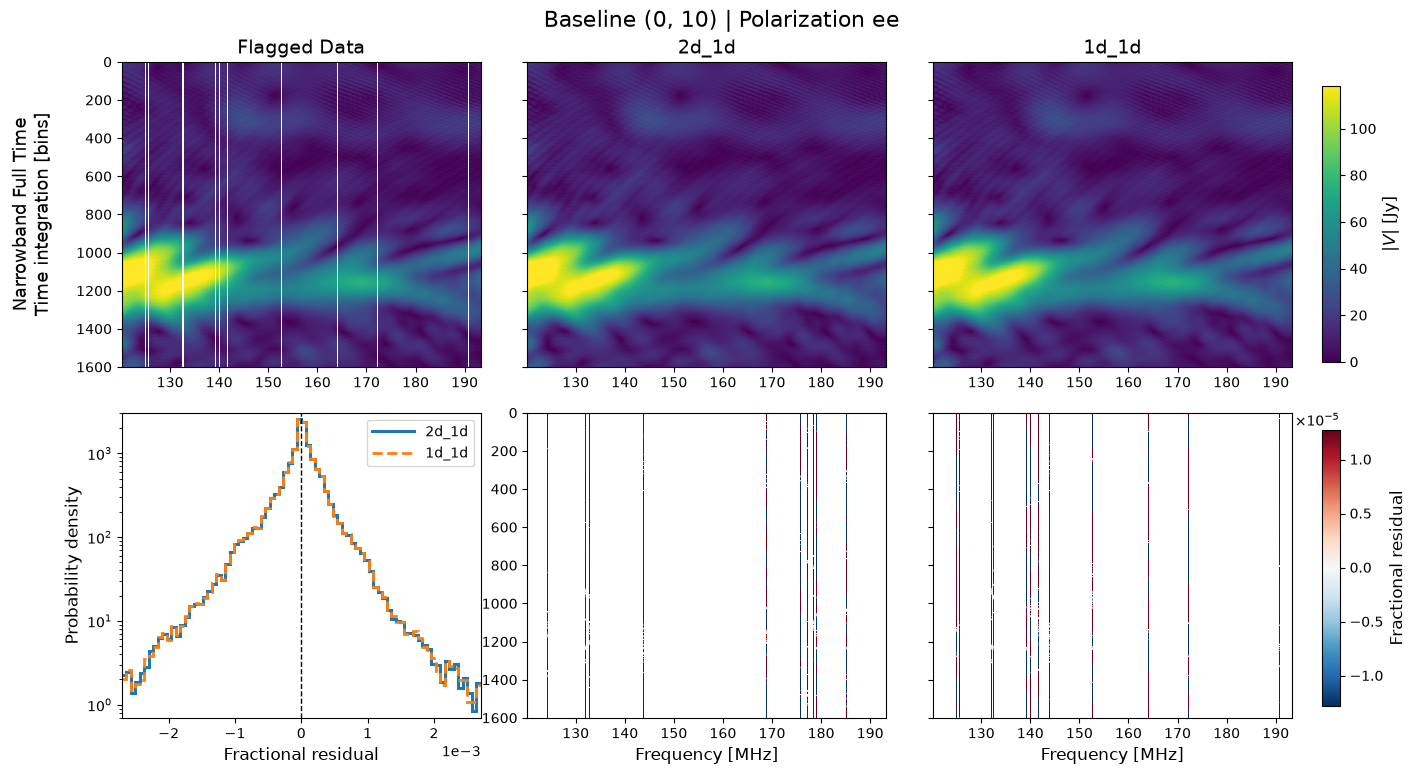

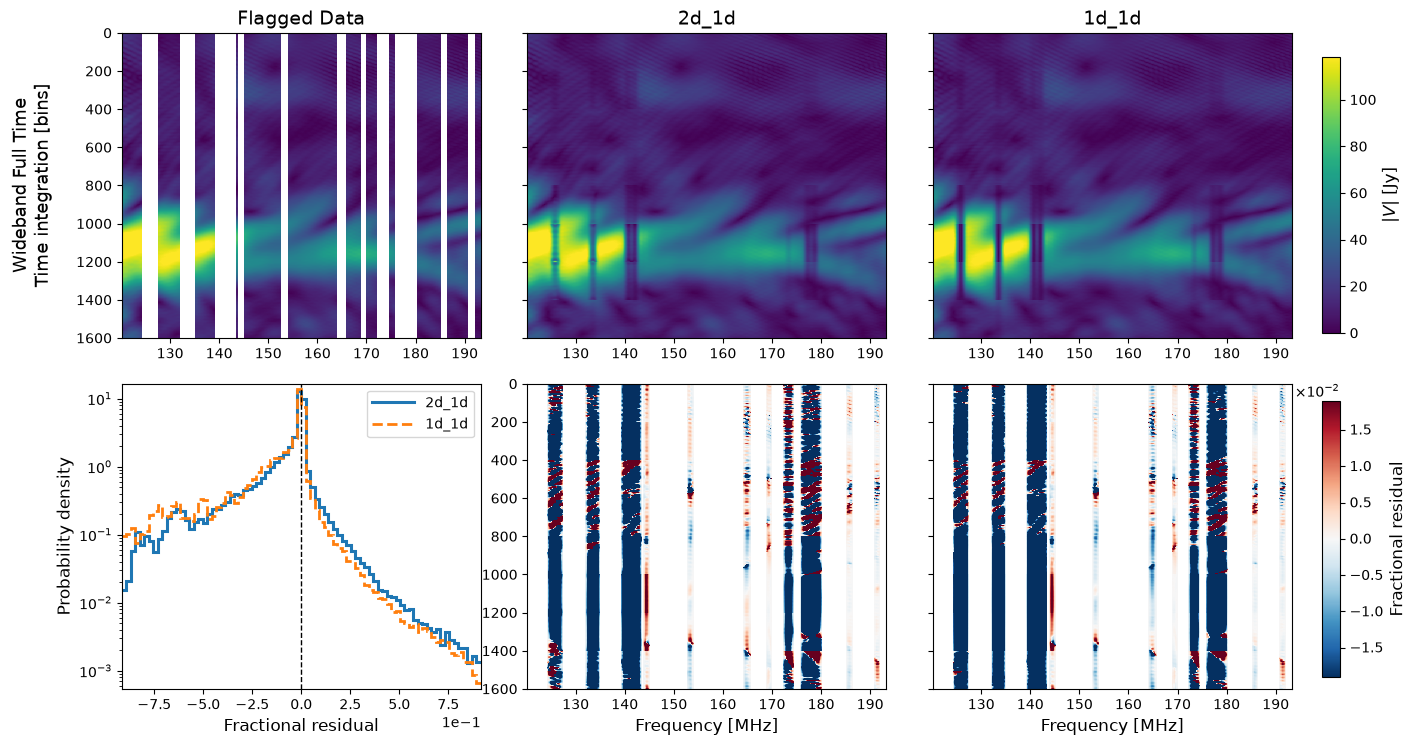

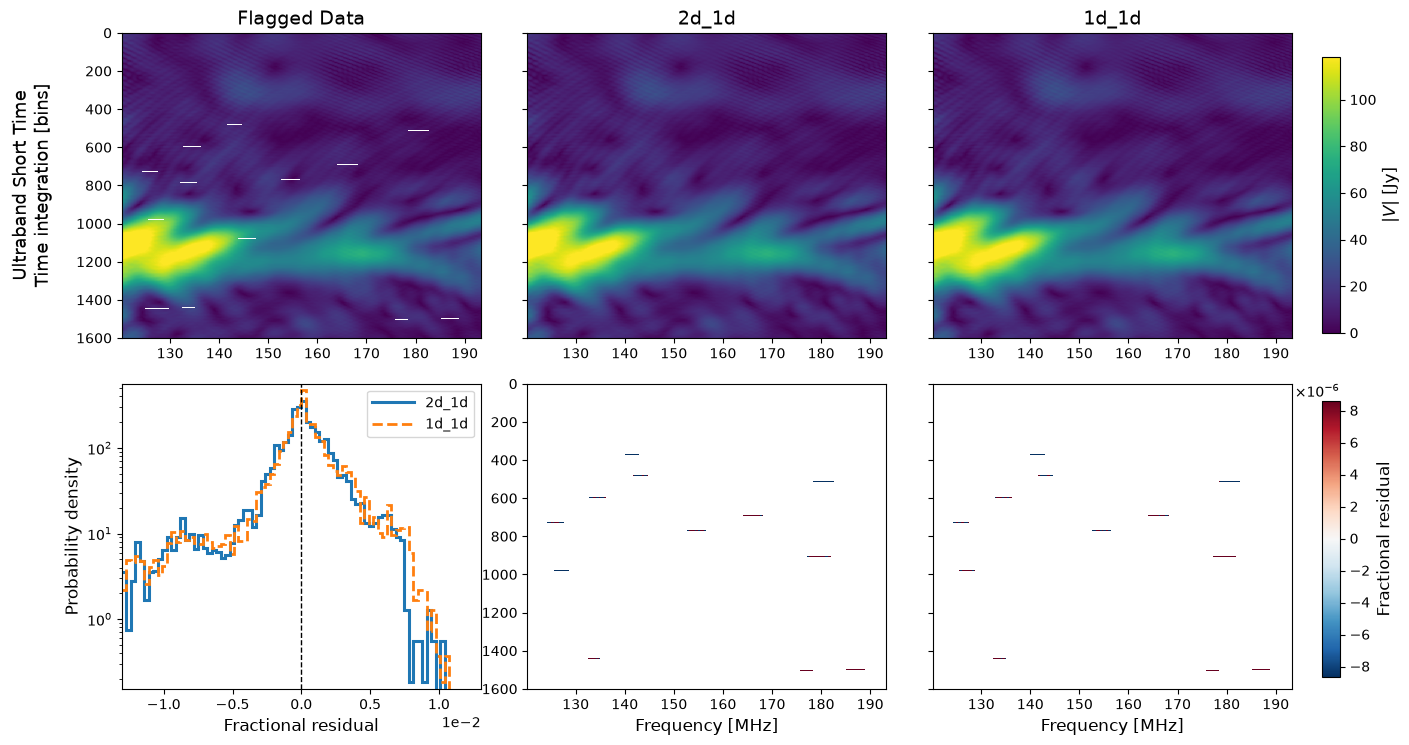

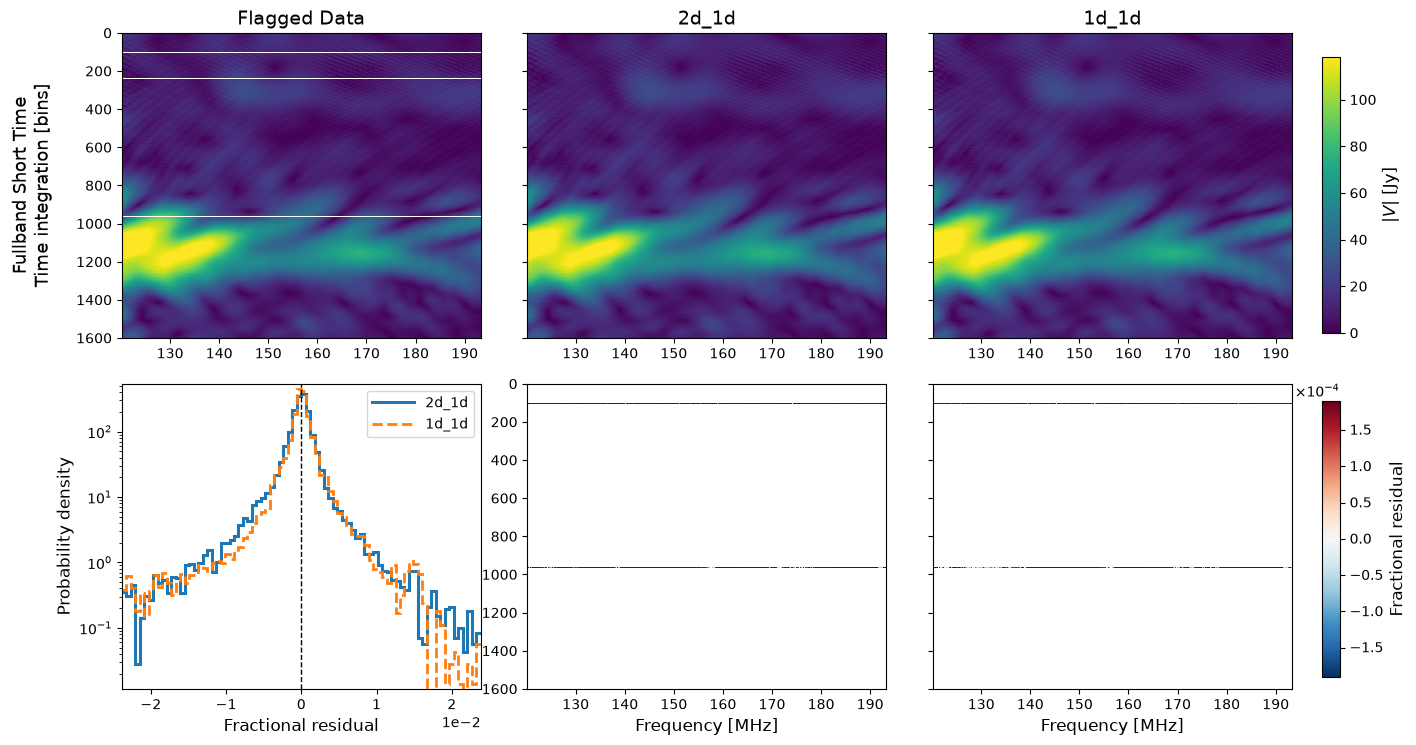

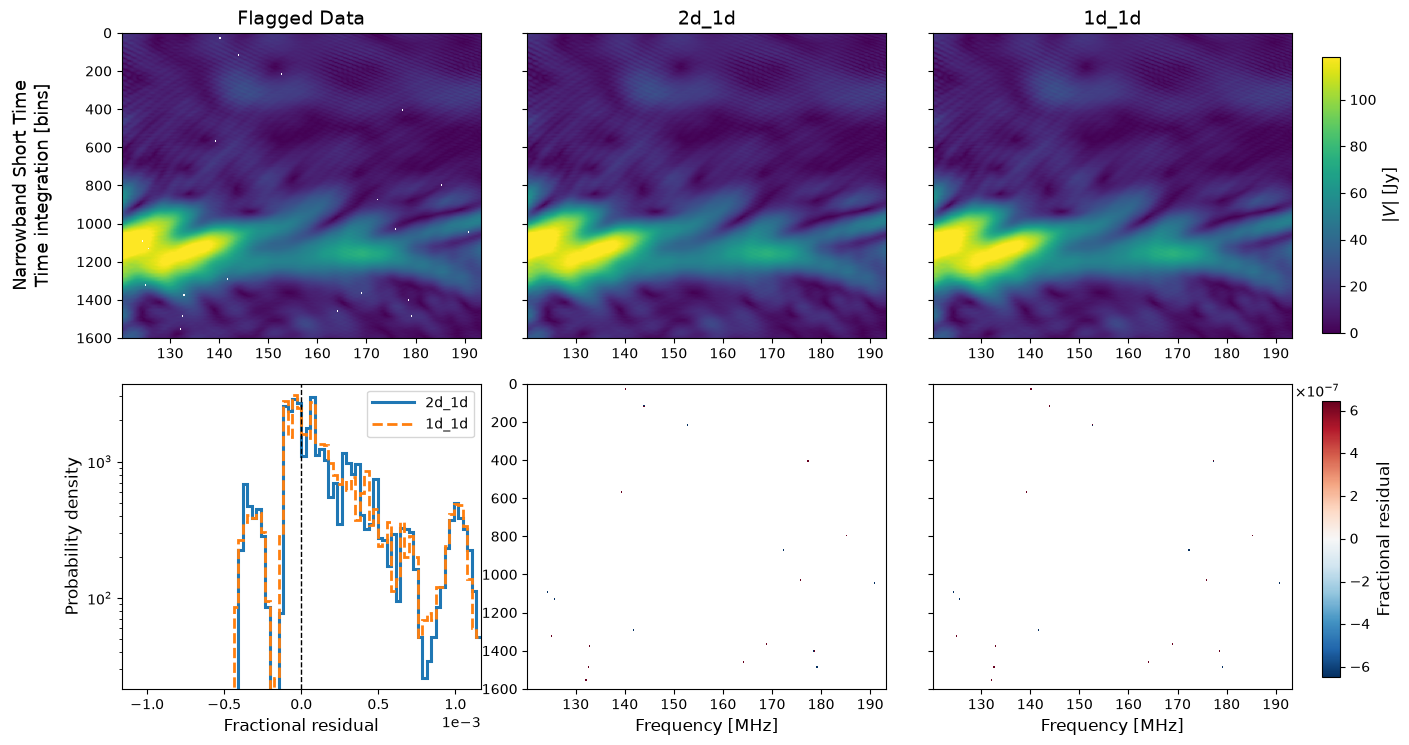

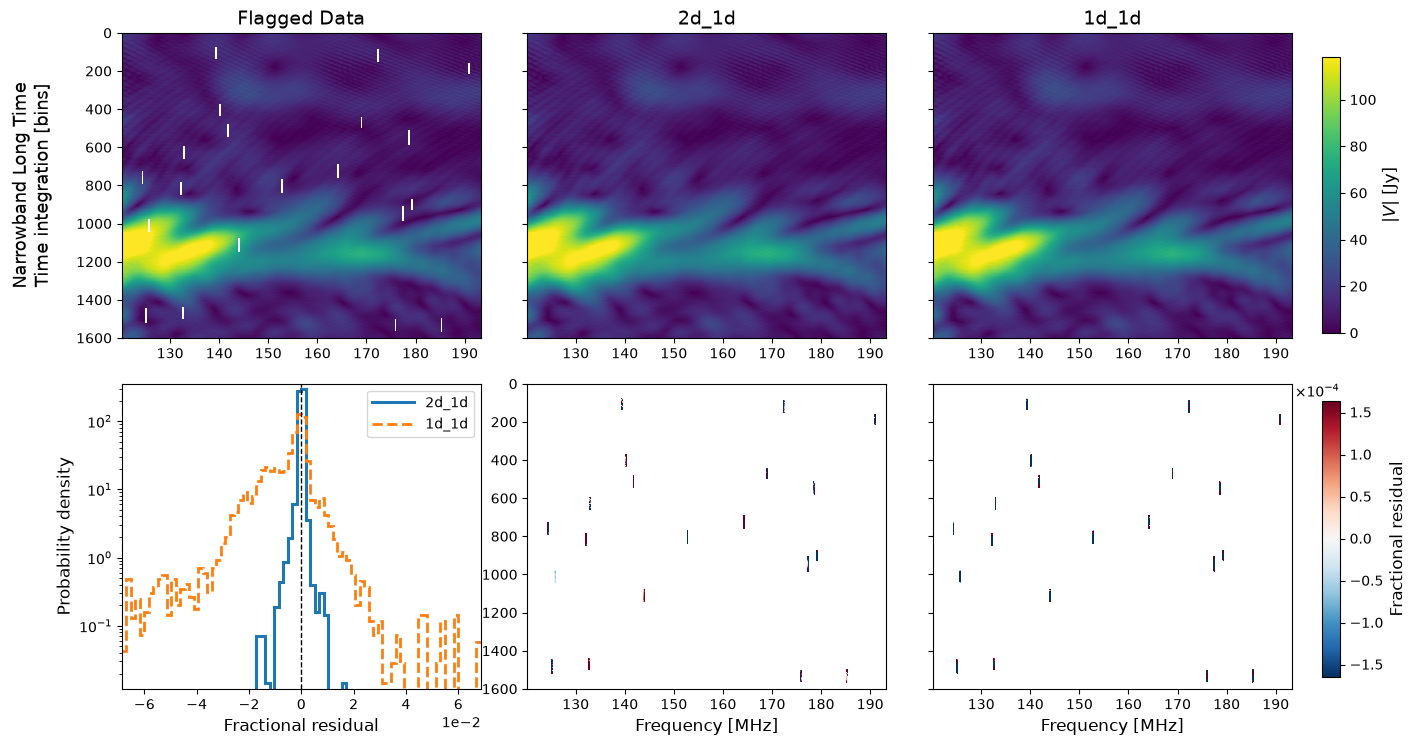

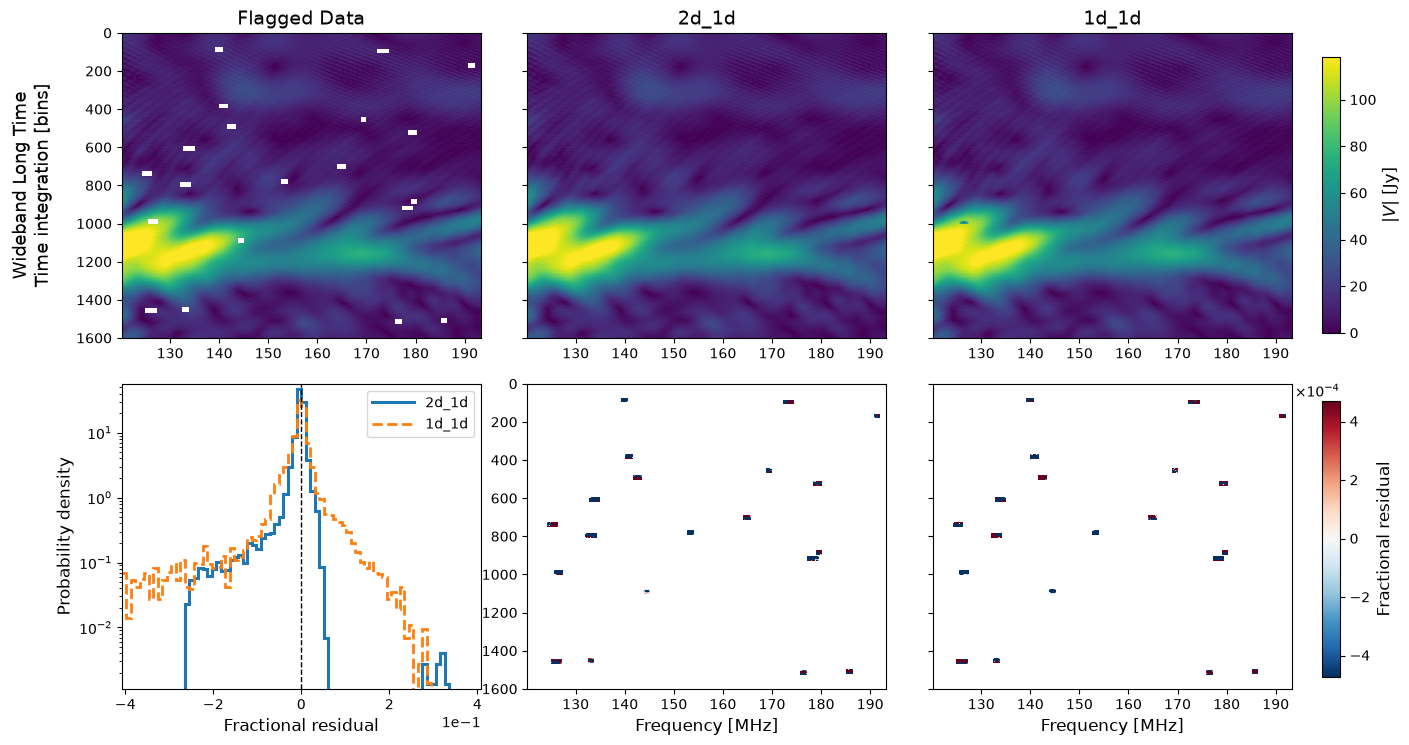

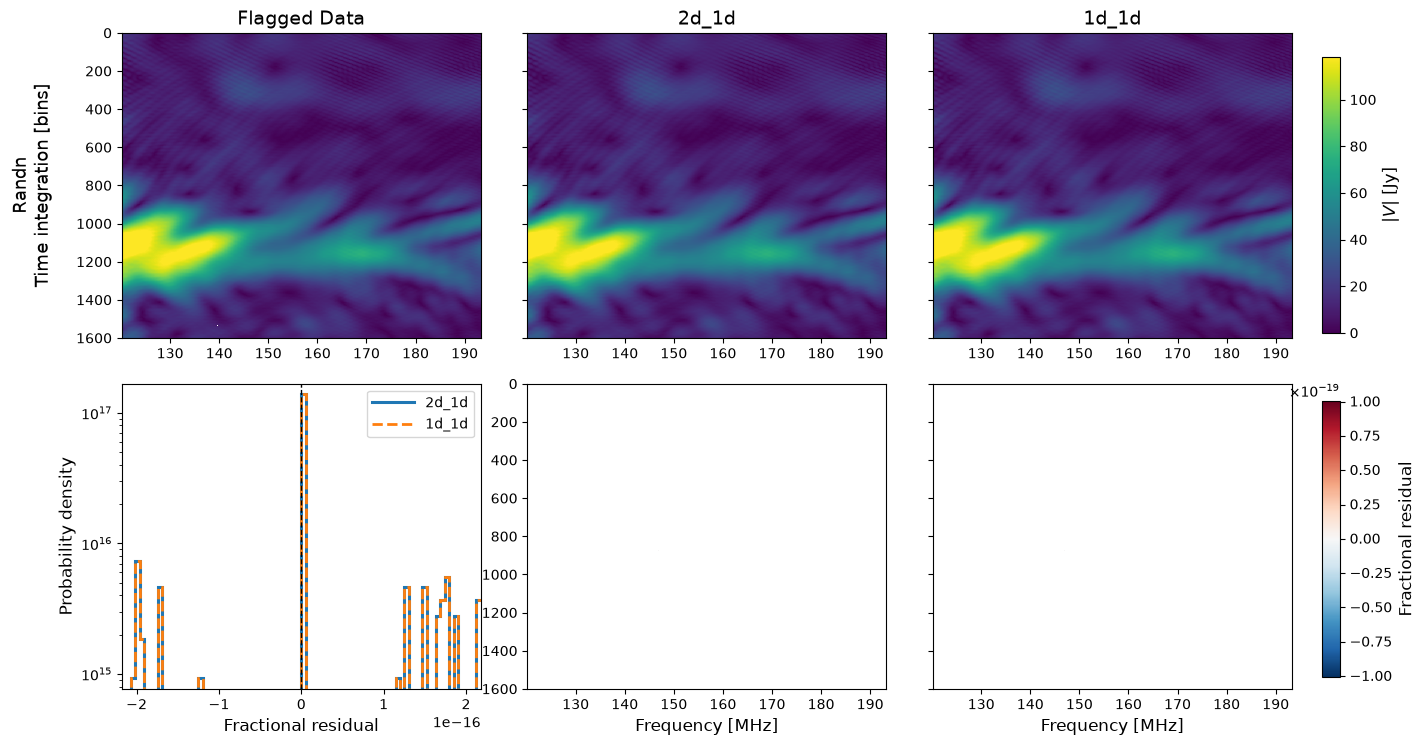

In [1]:
import gc
import glob
import inspect
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

import bayeslim as ba
import gpytorch
import gprlim

from bayeslim.fft import FFT
from gprlim import kernels
from pyuvdata import UVData


sys.path.append("./")

import utils_load
from utils_load import load_vd_inp, save_hist_residual

import utils_plot_no_append

importlib.reload(utils_plot_no_append)

from utils_plot_no_append import (
    add_residual_histogram,
    finalize_inpainting_figure,
    initialize_inpainting_figure,
    plot_data_image,
    plot_residual_image,
    sample_tensor,
)


torch.set_default_dtype(torch.float64)

sys.path.append("../../")

import gp_utils

importlib.reload(gp_utils)


print("gprlim path:")
print(gprlim.__file__)

print("\nutils_inpaint module path:")
print(inspect.getmodule(load_vd_inp).__file__)

print("\ngp_utils path:")
print(gp_utils.__file__)




def get_valid_hist_residual(data_true_all, data_inp_all, flags_all, eps):
    """
    Return only valid flagged-pixel residuals as a one-dimensional tensor.

    This avoids allocating a full [Nbls, Ntimes, Nfreqs] NaN array.
    """

    true_abs = data_true_all.abs()
    inp_abs = data_inp_all.abs()

    valid_mask = (
        flags_all
        & torch.isfinite(true_abs)
        & torch.isfinite(inp_abs)
        & (true_abs > eps)
    )

    return (inp_abs[valid_mask] - true_abs[valid_mask]) / true_abs[valid_mask]


def get_plot_residual(data_true_plot, data_inp_plot, flags_plot, eps):
    """
    Return the two-dimensional residual image for baseline index 0.
    """

    true_abs = data_true_plot.abs()
    inp_abs = data_inp_plot.abs()

    residual = torch.full_like(true_abs, torch.nan)

    valid_mask = (
        flags_plot
        & torch.isfinite(true_abs)
        & torch.isfinite(inp_abs)
        & (true_abs > eps)
    )

    residual[valid_mask] = (
        inp_abs[valid_mask] - true_abs[valid_mask]
    ) / true_abs[valid_mask]

    return residual


def load_inpainted_data(
    vd,
    bl,
    flag_typesi,
    add_real_flags,
    inpaint_method,
    freq_chans,
    time_ints,
    polsi,
    device,
    Ntime_chunks,
):
    """
    Load one inpainting method from disk.
    """

    return load_vd_inp(
        root_dir=(
            "/Volumes/YUNYUNShao/"
            "radio_gpr_work_great_lake/"
            "3.shao_instru/inpaint_results"
        ),
        vd=vd,
        bl=bl,
        flag_typesi=flag_typesi,
        add_real_flags=add_real_flags,
        inpaint_method=inpaint_method,
        freq_chans=freq_chans,
        time_ints=time_ints,
        polsi=polsi,
        device=device,
        Ntime_chunks=Ntime_chunks,
    )


gpytorch.settings.max_cholesky_size._set_value(1_000)

torch.set_default_dtype(torch.float64)
device = "cpu"


# ============================================================
# Settings
# ============================================================

flag_file = (
    "/Users/alliswell48/radio_gpr_work/shao1/1.ideal_mock/"
    "gpr_data/version2/"
    "zen.h6c_idr3.2459951.flag_waterfall_round2.npz"
)

freq_chans = range(0, 600)
time_ints = range(80, 1680)

inflate_data = False
add_gains = False
add_noise = False
add_reflection = False

inpaint_method_all = ["2d_1d", "1d_1d"]

Ntime_chunks = 200
add_real_flags = False

flag_types_all = [
    "narrowband_full_time",
    "wideband_full_time",
    "ultraband_short_time",
    "fullband_short_time",
    "narrowband_short_time",
    "narrowband_long_time",
    "wideband_long_time",
    "randn",
]

polsi = "ee"
blall = [(0, 1), (0, 5), (0, 10)]

dfile = sorted(
    glob.glob(
        "/Volumes/YUNYUNShao/gpr_data/corrupted data/"
        "zen.h6c_idr2_validation.24582*.sum.coupled.h5"
    )
)


# ============================================================
# Load autocorrelation and metadata
# ============================================================

vd, meta = gp_utils.load_uvdata(
    dfile,
    bls=[(0, 0)],
    pols=[polsi],
    time_ints=time_ints,
    freq_chans=freq_chans,
)

autocorr = vd.data[0, 0]

freqs = meta["freqs"] / 1e6
lsts = meta["lsts"]
times = (meta["times"] - meta["times"][0]) * 24 * 3600

Ntimes = len(times)
Nfreqs = len(freqs)
reds = meta["reds"]

antp = meta["antp"]
ants = list(antp.keys())
antpos = torch.stack(list(antp.values()))

red_bls = meta["bls"]
all_pols = meta["pols"]

noise_amp = autocorr.real / np.sqrt(
    np.diff(meta["times"])[0] * 24 * 3600
    * np.diff(meta["freqs"])[0]
)


# ============================================================
# Baseline loop
# ============================================================

for bl in blall:
    red_ind = np.where([bl in red for red in reds])[0][0]
    bls = reds[red_ind][:]
    bl_vec = antp[bls[0][1]] - antp[bls[0][0]]
    bl_len = bl_vec.norm()

    vd, meta = gp_utils.load_uvdata(
        dfile,
        bls=bls,
        time_ints=time_ints,
        freq_chans=freq_chans,
        pols=[polsi],
        device=device,
    )

    if inflate_data and vd.Nbls == 1:
        vd = vd.inflate_by_redundancy(bls=reds[red_ind])

    if add_reflection:
        vd.data *= (
            1
            + 1e-2
            * (
                torch.exp(2j * np.pi * 2000e-9 * freqs * 1e6)
                + torch.exp(-2j * np.pi * 2000e-9 * freqs * 1e6)
            )
        )

    if add_gains:
        G = torch.randn(vd.Nbls) / 10 + 1
        vd.data *= G[:, None, None]

    ns_draw = torch.randn_like(vd.data) * noise_amp * 1e-10

    if add_noise:
        ns_draw = torch.randn_like(vd.data) * noise_amp * 1e-6
        vd.data += ns_draw

    FT1 = FFT(
        dim=-1,
        N=vd.data.shape[-1],
        ndim=2,
        window="bh",
        dx=(freqs[1] - freqs[0]) / 1e3,
    )

    FT2 = FFT(
        dim=-2,
        N=vd.data.shape[-2],
        ndim=2,
        window="bh",
        dx=(lsts[1] - lsts[0]) * 12 / np.pi * 3600 / 1e3,
    )

    # ========================================================
    # Flag loop
    # ========================================================

    for flag_idx, flag_typesi in enumerate(flag_types_all):
        flag_types = [flag_typesi]
        flag_N = [20]

        flags = gp_utils.simulate_flags(
            flag_types,
            flag_N,
            Ntimes,
            Nfreqs,
            seed=0,
        )

        if add_gains:
            flags = flags.expand(vd.data.shape[-3:]).clone()

            for i in range(1, vd.Nbls):
                flags[i] = gp_utils.simulate_flags(
                    flag_types,
                    flag_N,
                    Ntimes,
                    Nfreqs,
                    seed=i,
                )

        if add_real_flags:
            flg = np.load(flag_file)["flags"][time_ints][:, freq_chans, 0]
            flags += torch.as_tensor(flg, device=device)

        flags = flags.bool()

        flagged_times = flags.all(
            dim=-1,
            keepdim=True,
        ).expand_as(flags)

        noise_var = noise_amp.pow(2).expand(flags.shape).clone() * 1e-5
        noise_var[flags] = noise_var.mean() * 1e6

        # ====================================================
        # Shared true-data quantities
        # ====================================================

        data_true_all = vd.data[0, 0, :]
        data_true_plot = data_true_all[0]

        flags_all = flags.expand_as(data_true_all).bool()
        flags_plot = flags_all[0]

        flagged_data = data_true_plot.clone()
        flagged_data[flags_plot] = torch.nan

        dmax = torch.quantile(
            data_true_plot.abs().detach().cpu(),
            0.99,
        ).item()

        eps = torch.finfo(data_true_plot.real.dtype).eps

        extent = [
            float(freqs[0]),
            float(freqs[-1]),
            Ntimes,
            0,
        ]

        # ====================================================
        # First pass:
        # calculate common plotting limits
        # ====================================================

        max_samples_per_method = 200_000

        hist_sample_all = torch.empty(
            len(inpaint_method_all) * max_samples_per_method,
            dtype=torch.float64,
        )

        hist_sample_count = 0
        resid_max = 0.0


        for inpaint_methodi in inpaint_method_all:

            vd_inp = load_inpainted_data(
                vd=vd,
                bl=bl,
                flag_typesi=flag_typesi,
                add_real_flags=add_real_flags,
                inpaint_method=inpaint_methodi,
                freq_chans=freq_chans,
                time_ints=time_ints,
                polsi=polsi,
                device=device,
                Ntime_chunks=Ntime_chunks,
            )

            data_inp_all = vd_inp.data[0, 0, :]
            data_inp_plot = data_inp_all[0]

            # ------------------------------------------------
            # Histogram residual
            # ------------------------------------------------

            valid_hist_resid = get_valid_hist_residual(
                data_true_all=data_true_all,
                data_inp_all=data_inp_all,
                flags_all=flags_all,
                eps=eps,
            )

            save_hist_residual(
                valid_hist_resid=valid_hist_resid,
                bl=bl,
                flag_typesi=flag_typesi,
                add_real_flags=add_real_flags,
                inpaint_method=inpaint_methodi,
                freq_chans=freq_chans,
                time_ints=time_ints,
                polsi=polsi,
                Ntime_chunks=Ntime_chunks,
            )

            hist_sample = sample_tensor(
                valid_hist_resid,
                max_samples=max_samples_per_method,
                take_abs=True,
            )

            if hist_sample.numel() > 0:
                sample_end = (
                    hist_sample_count
                    + hist_sample.numel()
                )

                hist_sample_all[
                    hist_sample_count:sample_end
                ] = hist_sample

                hist_sample_count = sample_end

            # ------------------------------------------------
            # Residual-image limit
            # ------------------------------------------------

            frac_resid_plot = get_plot_residual(
                data_true_plot=data_true_plot,
                data_inp_plot=data_inp_plot,
                flags_plot=flags_plot,
                eps=eps,
            )

            valid_plot_resid = frac_resid_plot[
                torch.isfinite(frac_resid_plot)
            ]

            if valid_plot_resid.numel() > 0:
                method_resid_max = (
                    valid_plot_resid
                    .abs()
                    .max()
                    .item()
                )

                resid_max = max(
                    resid_max,
                    method_resid_max,
                )

            del vd_inp
            del data_inp_all
            del data_inp_plot
            del valid_hist_resid
            del hist_sample
            del frac_resid_plot
            del valid_plot_resid

            gc.collect()


        # ====================================================
        # Histogram limit across all sampled methods
        # ====================================================

        if hist_sample_count > 0:
            hist_limit = torch.quantile(
                hist_sample_all[:hist_sample_count],
                0.995,
            ).item()

        else:
            hist_limit = 1.0

        del hist_sample_all


        # ====================================================
        # Residual-image limit
        # ====================================================

        if resid_max > 0 and np.isfinite(resid_max):
            resid_limit = resid_max / 2000

        else:
            resid_limit = 1.0
        # ====================================================
        # Titles and colormaps
        # ====================================================

        if flag_typesi is None:
            flag_title = "Real Flags" if add_real_flags else "No Flags"
        else:
            flag_title = flag_typesi.replace("_", " ").title()

        cmap_data = plt.cm.viridis.copy()
        cmap_data.set_bad("white")

        cmap_resid = plt.cm.RdBu_r.copy()
        cmap_resid.set_bad("white")

        # ====================================================
        # Initialize figure
        # ====================================================

        fig, axes, cax_data = initialize_inpainting_figure(
            inpaint_method_all=inpaint_method_all,
            flagged_data=flagged_data,
            extent=extent,
            dmax=dmax,
            cmap_data=cmap_data,
            flag_title=flag_title,
            bl=bl,
            polsi=polsi,
            flag_idx=flag_idx,
        )

        hist_ymin = np.inf
        hist_ymax = 0.0
        cax_resid = None

        # ====================================================
        # Second pass:
        # load one method, draw immediately, then release it
        # ====================================================

        for j, inpaint_methodi in enumerate(inpaint_method_all):
            col = j + 1

            vd_inp = load_inpainted_data(
                vd=vd,
                bl=bl,
                flag_typesi=flag_typesi,
                add_real_flags=add_real_flags,
                inpaint_method=inpaint_methodi,
                freq_chans=freq_chans,
                time_ints=time_ints,
                polsi=polsi,
                device=device,
                Ntime_chunks=Ntime_chunks,
            )

            data_inp_all = vd_inp.data[0, 0, :]
            data_inp_plot = data_inp_all[0]

            # ------------------------------------------------
            # Row 0: inpainted data
            # ------------------------------------------------

            plot_data_image(
                ax=axes[0, col],
                data=data_inp_plot,
                extent=extent,
                cmap=cmap_data,
                vmin=0,
                vmax=dmax,
                title=inpaint_methodi,
                title_fontsize=14,
            )

            axes[0, col].set_ylim(Ntimes, 0)

            # ------------------------------------------------
            # Row 1: residual image
            # ------------------------------------------------

            frac_resid_plot = get_plot_residual(
                data_true_plot=data_true_plot,
                data_inp_plot=data_inp_plot,
                flags_plot=flags_plot,
                eps=eps,
            )

            cax_resid = plot_residual_image(
                ax=axes[1, col],
                residual=frac_resid_plot,
                extent=extent,
                cmap=cmap_resid,
                residual_limit=resid_limit,
                xlabel="Frequency [MHz]",
                label_fontsize=12,
            )

            axes[1, col].set_ylim(Ntimes, 0)

            # ------------------------------------------------
            # Histogram
            # ------------------------------------------------

            valid_hist_resid = get_valid_hist_residual(
                data_true_all=data_true_all,
                data_inp_all=data_inp_all,
                flags_all=flags_all,
                eps=eps,
            )

            method_hist_ymin, method_hist_ymax = add_residual_histogram(
                ax=axes[1, 0],
                hist_values=valid_hist_resid,
                method=inpaint_methodi,
                method_index=j,
                hist_limit=hist_limit,
                bins=80,
                display_fractionx=1.0,
            )

            hist_ymin = min(
                hist_ymin,
                method_hist_ymin,
            )

            hist_ymax = max(
                hist_ymax,
                method_hist_ymax,
)

            del vd_inp
            del data_inp_all
            del data_inp_plot
            del frac_resid_plot
            del valid_hist_resid

            gc.collect()

        # ====================================================
        # Finalize and show figure
        # ====================================================

        fig, axes = finalize_inpainting_figure(
            fig=fig,
            axes=axes,
            cax_data=cax_data,
            cax_resid=cax_resid,
            hist_limit=hist_limit,
            hist_ymin=hist_ymin,
            hist_ymax=hist_ymax,
            nmethods=len(inpaint_method_all),
            display_fractionx=1.0,
            display_fractiony=1.2,
        )

        plt.show()
        plt.close(fig)

        # ====================================================
        # Clean current flag data
        # ====================================================

        del fig
        del axes
        del cax_data
        del cax_resid
        del flagged_data
        del flags_all
        del flags_plot
        del noise_var

        gc.collect()

    del vd
    gc.collect()


In [3]:
1

1

In [ ]:
import importlib
import utils_plot_no_append

importlib.reload(utils_plot_no_append)

from utils_plot_no_append import (
    add_residual_histogram,
    finalize_inpainting_figure,
    initialize_inpainting_figure,
    plot_data_image,
    plot_residual_image,
    sample_tensor,
)

In [ ]:
1